# Chapter 8 Sending Information to Servers

## 1. How Forms Work

## 2. Rendering Widgets

✅ 생성된 InputLayout 객체 수: 3개
 - [input ] 위치: (x= 60, y=21.75) | 크기: 200px x 18px
 - [input ] 위치: (x= 85, y=44.25) | 크기: 200px x 18px
 - [button] 위치: (x= 13, y=66.75) | 크기: 200px x 18px

✅ 렌더링된 사각형(DrawRect): 3개
 - [lightblue ] 위치: (60, 21.75) | 크기: 200px x 18px
 - [lightblue ] 위치: (85, 44.25) | 크기: 200px x 18px
 - [orange    ] 위치: (13, 66.75) | 크기: 200px x 18px

✅ 렌더링된 텍스트(DrawText): 5개
 - 'Name:' (x=13, y=21.75)
 - '1' (x=60, y=21.75)
 - 'Comment:' (x=13, y=44.25)
 - '2' (x=85, y=44.25)
 - 'Submit!' (x=13, y=66.75)


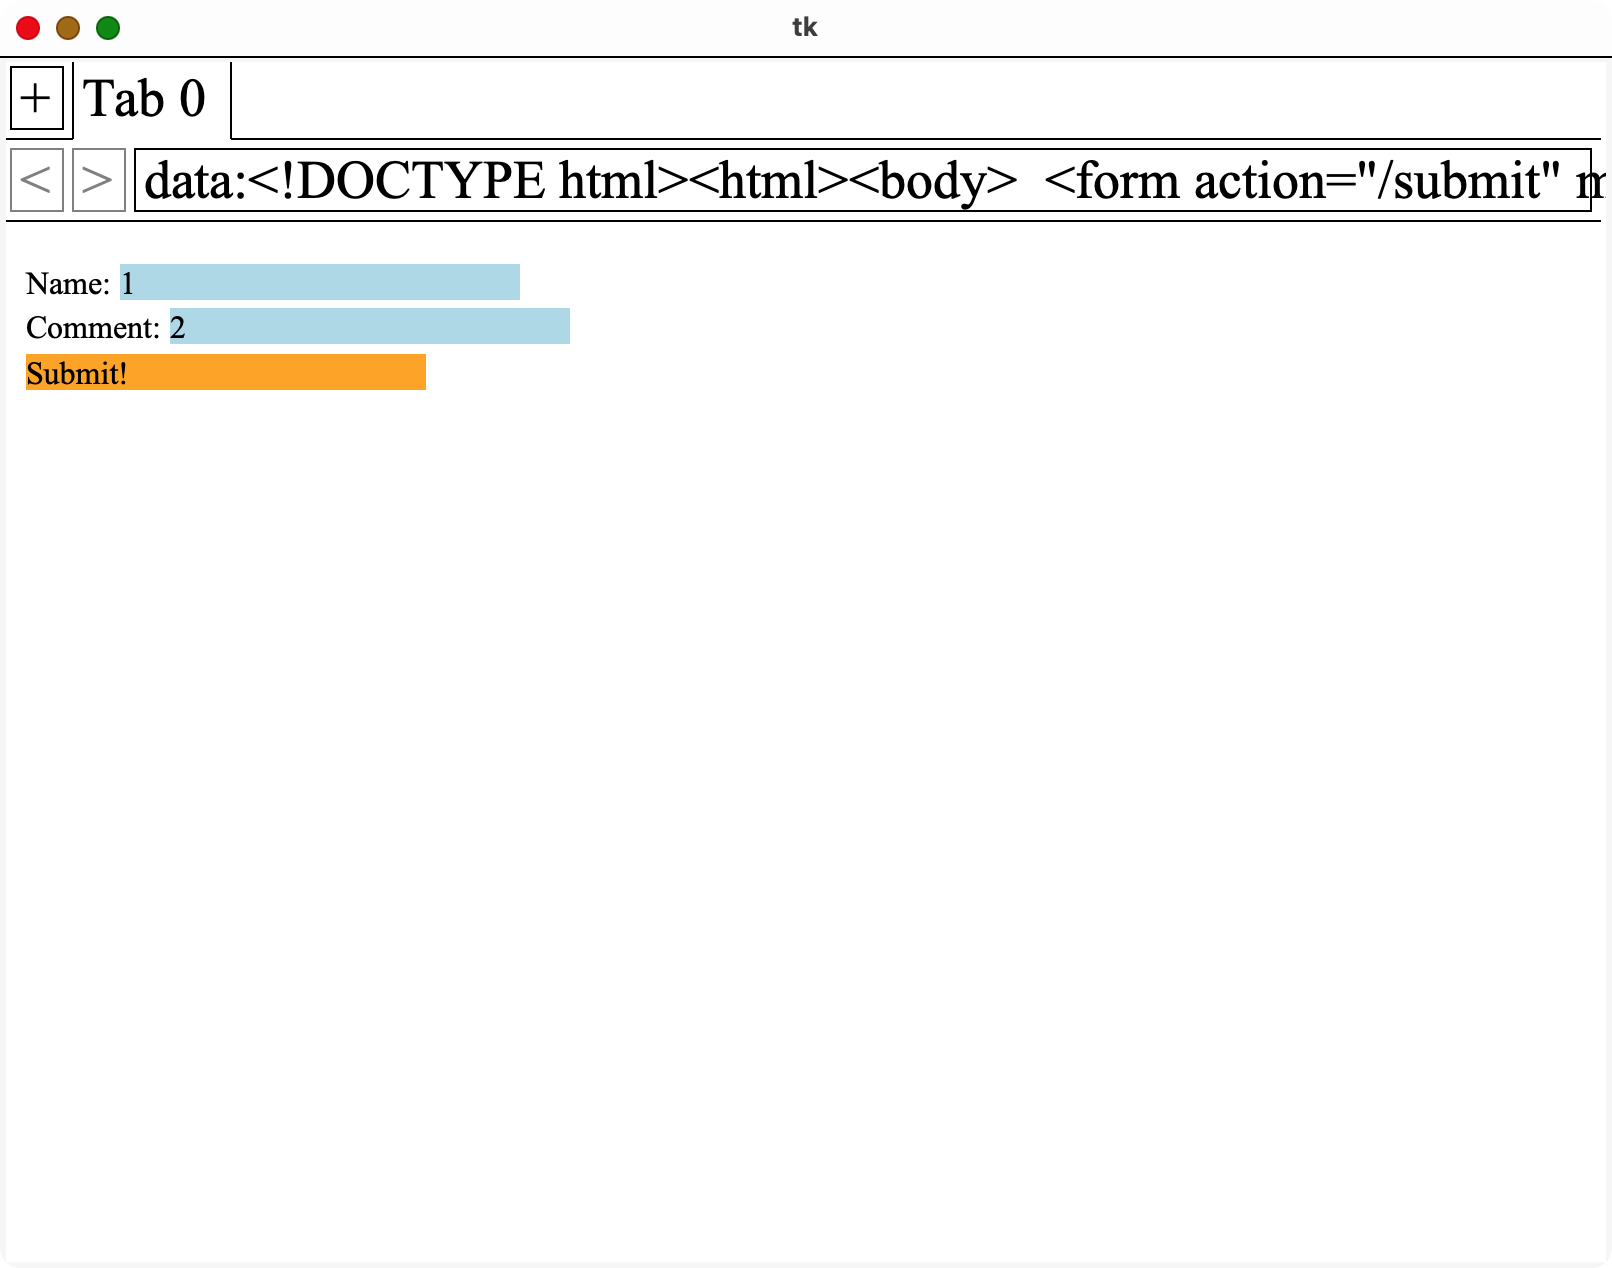

In [1]:
import time
import importlib
import browser.css
import browser.layout
import browser.browser

# 💡 모듈 핫 리로드
importlib.reload(browser.css)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout, DrawRect, DrawText
from browser.html import tree_to_list
from browser.tk_capture import display_tk_window

# 1. 책 8.1 & 8.2 절 예제 HTML (Figure 1 폼 요소 테스트)
html_content = """<!DOCTYPE html>
<html>
<body>
  <form action="/submit" method="post">
    <p>Name: <input name=name value=1></p>
    <p>Comment: <input name=comment value=2></p>
    <p><button>Submit!</button></p>
  </form>
</body>
</html>"""

# 2. 브라우저 생성 및 data: URL로 페이지 로드
browser = Browser()
browser.new_tab(URL("data:text/html," + html_content))

# 3. 레이아웃 트리 및 렌더링 명령 검증
tab = browser.active_tab
inputs = [obj for obj in tree_to_list(tab.document, []) if isinstance(obj, InputLayout)]
print(f"✅ 생성된 InputLayout 객체 수: {len(inputs)}개")
for inp in inputs:
    tag = inp.node.tag
    print(f" - [{tag:<6}] 위치: (x={inp.x:>3}, y={inp.y:>5.2f}) | 크기: {inp.width}px x {inp.height}px")

rects = [cmd for cmd in tab.display_list if isinstance(cmd, DrawRect)]
print(f"
✅ 렌더링된 사각형(DrawRect): {len(rects)}개")
for r in rects:
    w, h = int(r.rect.right - r.rect.left), int(r.rect.bottom - r.rect.top)
    print(f" - [{r.color:<10}] 위치: ({r.rect.left}, {r.rect.top}) | 크기: {w}px x {h}px")

texts = [cmd for cmd in tab.display_list if isinstance(cmd, DrawText)]
print(f"
✅ 렌더링된 텍스트(DrawText): {len(texts)}개")
for t in texts:
    print(f" - '{t.text}' (x={t.rect.left}, y={t.rect.top})")

# 4. 🌟 핵심: 창 준비 후 명시적 재드로잉(draw) 및 OS 버퍼 동기화
browser.draw()
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

# 5. 주피터 노트북에 브라우저 화면 인라인 출력
display_tk_window(browser.window, settle_seconds=0.5)
